In [1]:
import sys

In [2]:
sys.path.append('../')

In [3]:
import my_functions

In [4]:
from sklearn.datasets import make_blobs
from imblearn.over_sampling import ADASYN


In [5]:
blobs_random_seed = 42
centers = [(0,0), (5,5)]
cluster_std = 1.5
n_features = 2
n_samples = 1600

In [62]:
X, y = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=centers,
    cluster_std=2,
    random_state=42,
)

X = pd.DataFrame(X, columns=['varA', 'varB',])
y = pd.Series(y)

In [63]:
data1 = X[y==0]
data2 = X[y==1].sample(200, random_state=40)

In [64]:
X = pd.concat([data1, data2], axis=0)

In [65]:
X.shape, y.shape

((1000, 2), (1600,))

In [66]:
y = y.loc[X.index]

In [67]:
X.shape, y.shape

((1000, 2), (1000,))

# ADASYN

In [68]:
from imblearn.over_sampling import ADASYN

In [69]:
?ADASYN

Init signature: ADASYN(*, sampling_strategy='auto', random_state=None, n_neighbors=5)
Docstring:     
Oversample using Adaptive Synthetic (ADASYN) algorithm.

This method is similar to SMOTE but it generates different number of
samples depending on an estimate of the local distribution of the class
to be oversampled.

Read more in the :ref:`User Guide <smote_adasyn>`.

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the majority class.

        .. warning::
           ``float`` is only available f

In [70]:
ada = ADASYN(sampling_strategy='auto', 
       random_state=0, 
       n_neighbors=5)

X_res, y_res = ada.fit_resample(X, y)

In [71]:
X.shape, X_res.shape

((1000, 2), (1595, 2))

In [72]:
y.value_counts(), y_res.value_counts()

(0    800
 1    200
 Name: count, dtype: int64,
 0    800
 1    795
 Name: count, dtype: int64)

In [73]:
from my_functions import Scatterplot

In [74]:
?Scatterplot

Signature: Scatterplot(data1, class1, data2, class2, alpha=None)
Docstring:
Plot 2 Scatterplots.
1 Row and 2 columns, given the 2 provided datasets
Ex:

Without alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled)

With alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled, alpha=0.5)
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/my_functions.py
Type:      function

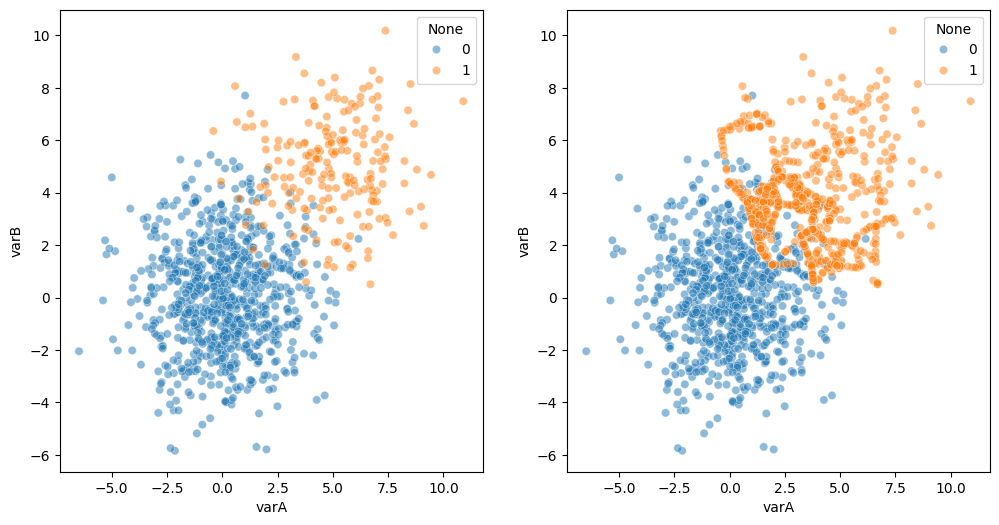

In [75]:
Scatterplot(X, y, X_res, y_res, alpha=0.5)